In [17]:
from constraints import get_experiment_folder
from pathlib import Path
from matplotlib import pyplot as plt 
import numpy as np
import torch
import kornia.contrib.distance_transform
from scipy import ndimage
FOLDER =get_experiment_folder(Path("ex3")/"losses")

In [18]:
from constraints.utils import signed_distance_scipy as signed_distance

def visu_sdf(data):
    fig, ax = plt.subplots()
    # Using matshow here just because it sets the ticks up nicely. imshow is faster.
    ax.matshow(data, cmap='seismic')

    for (i, j), z in np.ndenumerate(data):
        ax.text(j, i, '{:0.1f}'.format(z), ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.3'))


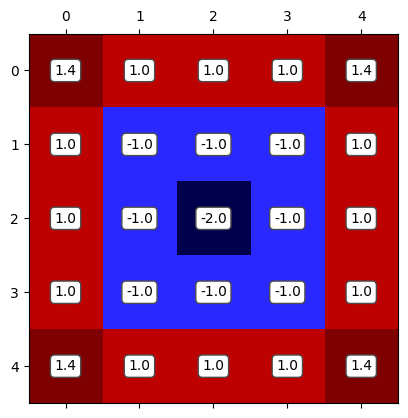

In [4]:
layer1 = np.array([[0,0,0,0,0],[0,1,1,1,0],[0,1,1,1,0],[0,1,1,1,0],[0,0,0,0,0]])
layer2 = np.array([[0,0,0,0,0],[0,0,0,0,0],[0,0,1,0,0],[0,0,0,0,0],[0,0,0,0,0]])
mask = np.stack((layer1, layer2), axis=-1)
# plt.imshow(mask)
plt.show()
sdf = signed_distance(mask)
visu_sdf(sdf[:,:,0])
plt.show()

In [19]:
mask = plt.imread("mask.png")

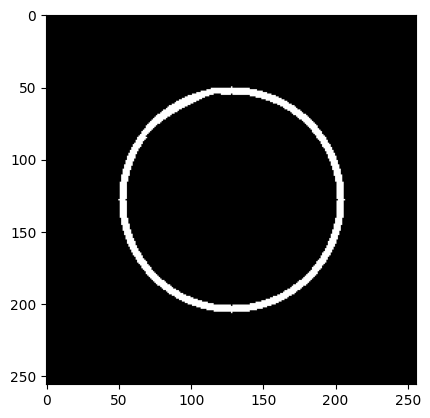

In [22]:
plt.imshow(mask[:,:,0],cmap="gray")

(256, 256, 3)


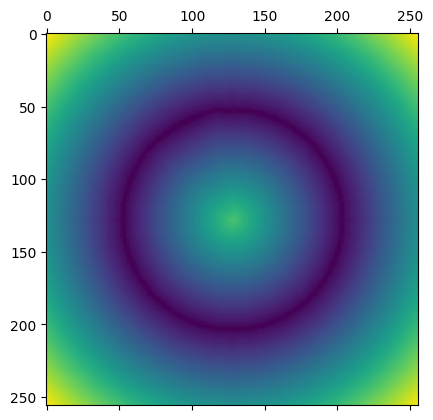

In [24]:
sdf =signed_distance(mask)
print(sdf.shape)
plt.matshow(sdf[:,:,0])
# visu_sdf(sdf[:,:,0])


In [8]:
binary_back =sdf <0
assert np.all(binary_back[:,:,1] == mask[:,:,1])

# Kornia implementation

In [26]:
layer1 = np.array([[0,0,0,0,0],[0,1,1,1,0],[0,1,1,1,0],[0,1,1,1,0],[0,0,0,0,0]])
layer2 = np.array([[0,0,0,0,0],[0,0,0,0,0],[0,0,1,0,0],[0,0,0,0,0],[0,0,0,0,0]])
# mask = np.stack((layer1, layer2), axis=-1)
mask = plt.imread("mask.png")

In [10]:
mask_torch = torch.from_numpy(mask).permute(2,0,1).unsqueeze(0).float()
sdf_torch = kornia.contrib.distance_transform(mask_torch)
sdf_reference = signed_distance(mask_torch)


In [11]:
diffs = sdf_torch - sdf_reference
diffs.shape

torch.Size([1, 3, 256, 256])

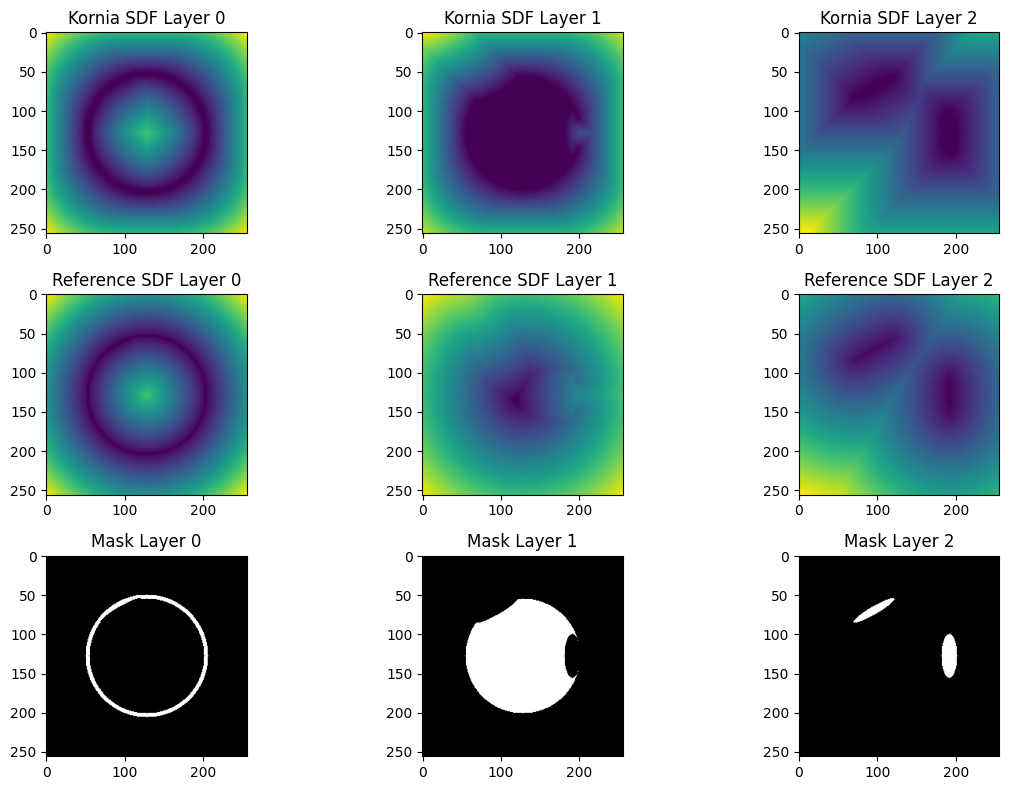

In [12]:
# plot side by side each layer of kornia and reference sdf
ax, axs = plt.subplots(3, 3, figsize=(12, 8))
for i in range(3):
    axs[0, i].imshow(sdf_torch[0, i].numpy(), )
    axs[0, i].set_title(f'Kornia SDF Layer {i}')
    axs[1, i].imshow(sdf_reference[0, i].numpy(),)
    axs[1, i].set_title(f'Reference SDF Layer {i}')
    axs[2,i].imshow(mask[:,:,i], cmap='gray')
    axs[2, i].set_title(f'Mask Layer {i}')
plt.tight_layout()


# Visu cached dataset

In [31]:
from constraints.utils import get_repo_root
from constraints.visu import show_torch_image
import numpy as np
import torch
ROOT = get_repo_root()
DATA = ROOT/"data"/"artificial/deformed/trn"
assert DATA.exists(), f"Data folder {DATA} does not exist. Please run `make` to generate the dataset."

(3, 256, 256)


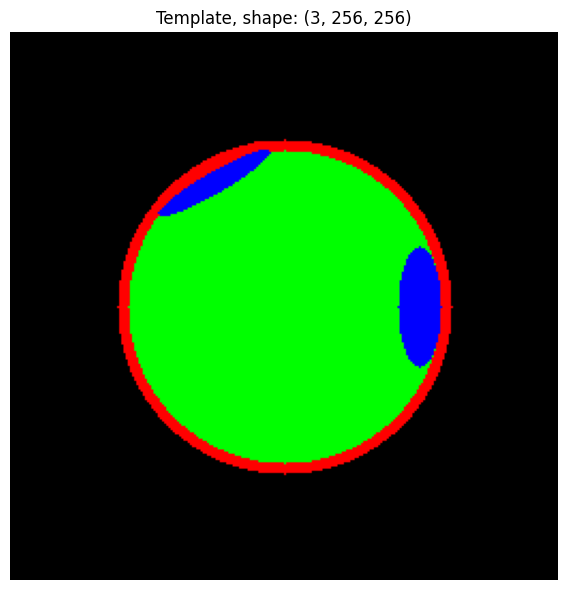

In [32]:
imgs = np.load(DATA/"img.npy", mmap_mode='r')
masks = np.load(DATA/"mask.npy", mmap_mode='r')
sdf_kornia = np.load(DATA/"sdf_kornia.npy", mmap_mode='r')
sdf_scipy = np.load(DATA/"sdf_scipy.npy", mmap_mode='r')
template = np.load(DATA/"template.npy", mmap_mode='r')
print(template.shape)
show_torch_image(torch.from_numpy(template), title=f"Template, shape: {template.shape}",cmap="gray")

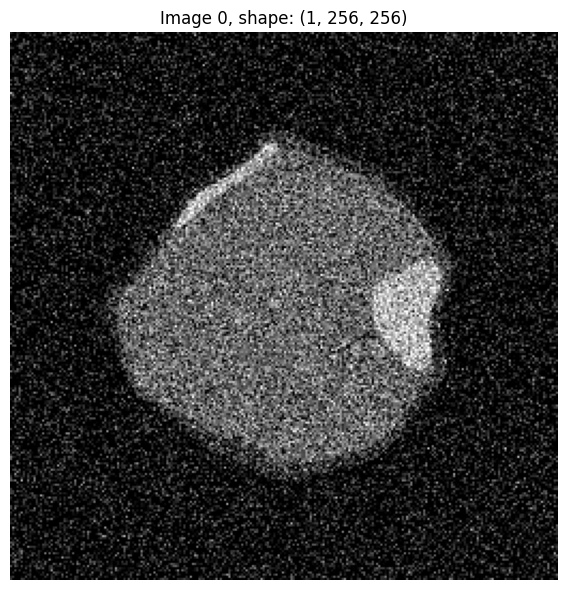

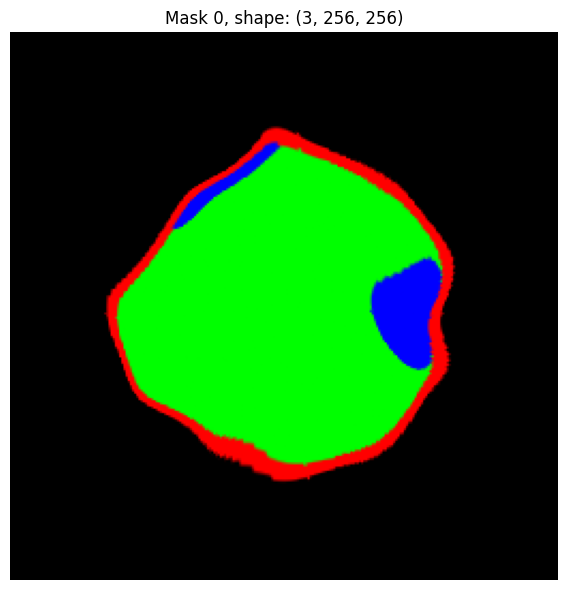

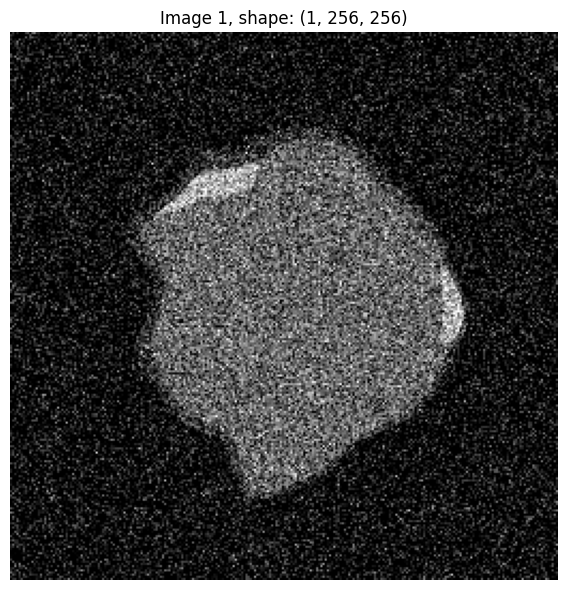

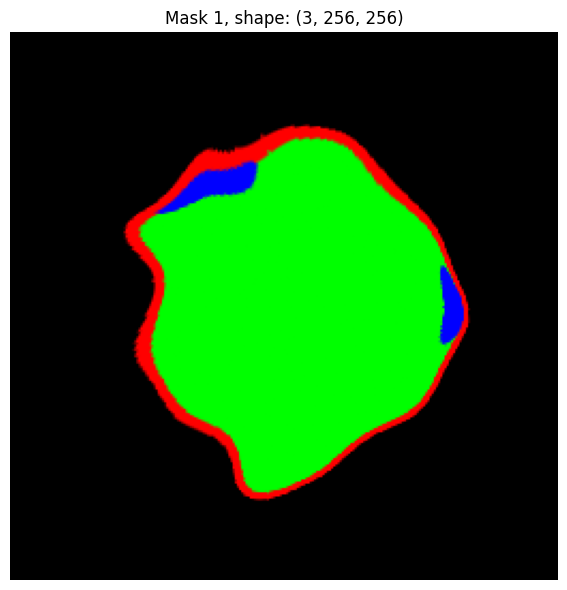

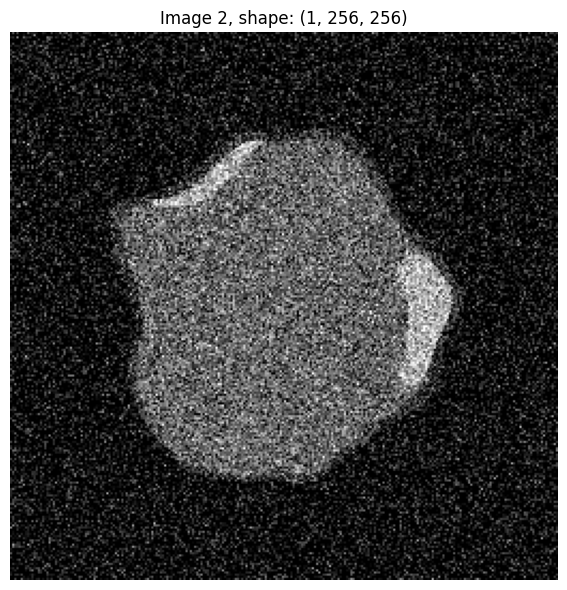

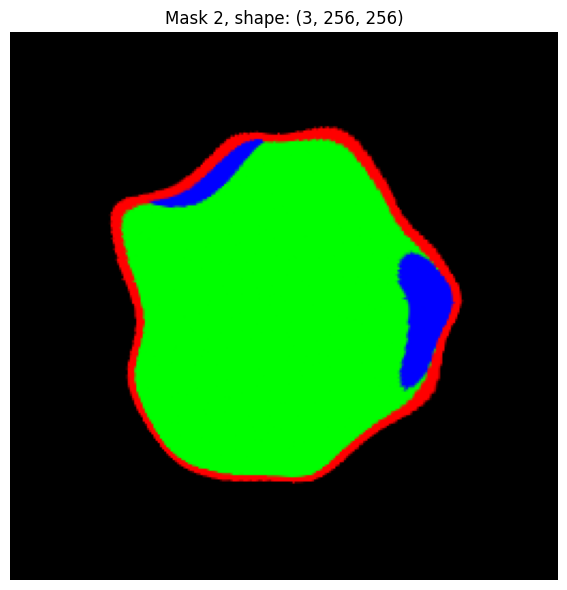

In [33]:

for i in range(3):
    show_torch_image(torch.from_numpy(imgs[i]), title=f"Image {i}, shape: {imgs[i].shape}",cmap="gray")
    show_torch_image(torch.from_numpy(masks[i]), title=f"Mask {i}, shape: {masks[i].shape}")
    

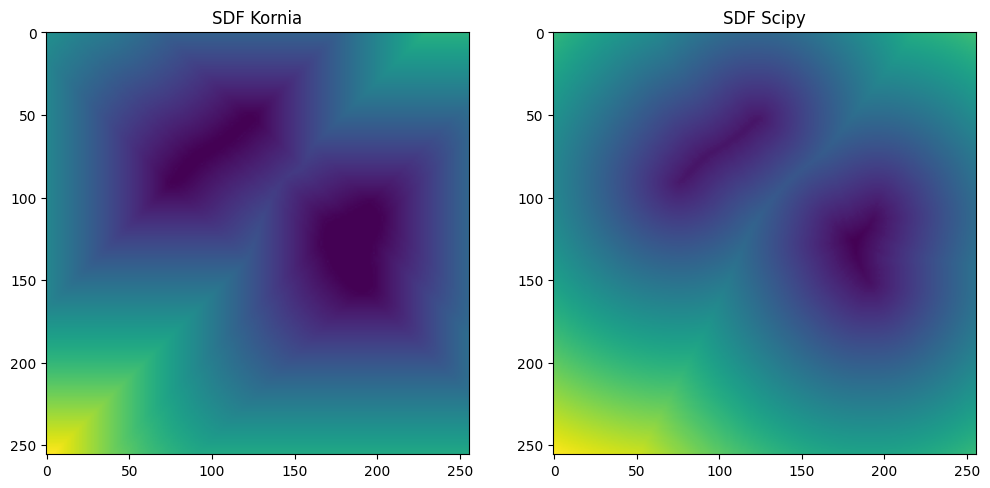

In [36]:
from matplotlib import pyplot as plt
# for first image show sdf_kornia and sdf_scipy side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(sdf_kornia[0,2],)
axs[0].set_title('SDF Kornia')
axs[1].imshow(sdf_scipy[0,2])
axs[1].set_title('SDF Scipy')
# show colorbar for both subplots
plt.show()